# Laboratorio 8 — Simulación del Álbum Panini FIFA 2026 parte no.2
### Arturo Lima - 24683 
### Jorge Villeda - 24932
## Etapa 3: Incorporacion del presupuesto y costo

Ahora se introduce un límite económico. Supongamos que el coleccionista dispone de un
presupuesto fijo y debe decidir si puede completar el álbum o no. Se simula la compra
secuencial de sobres hasta agotar el dinero o hasta completar la colección

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N = 100       # estampas distintas
S = 7         # estampas por sobre
R = 10_000    # simulaciones
PI = 9.50     # precio individual de cada sobre
PT = 1000   # presupuesto total 
np.random.seed(2026)

In [11]:
completo            = []
sobres_comprados    = []
distintas_obtenidas = []

for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)
    gasto     = 0
    sobres    = 0
    while gasto + PI <= PT and not coleccion.all():
        sobre   = np.random.randint(0, N, size=S)   # repetidas posibles dentro del sobre
        sobres += 1
        gasto  += PI
        for est in sobre:
            coleccion[est] = True
    completo.append(coleccion.all())
    sobres_comprados.append(sobres)
    distintas_obtenidas.append(coleccion.sum())

completo            = np.array(completo)
sobres_comprados    = np.array(sobres_comprados)
distintas_obtenidas = np.array(distintas_obtenidas)

In [12]:
prob_completar  = completo.mean()
esperado_sobres = sobres_comprados.mean()
no_completaron  = ~completo

print("RESULTADOS ETAPA 3 – PRESUPUESTO Q1 000")
print(f"Probabilidad de completar el álbum : {prob_completar:.4f}  ({prob_completar*100:.2f} %)")
print(f"Sobres esperados comprados          : {esperado_sobres:.2f}")

if no_completaron.any():
    esperado_distintas_no_exito = distintas_obtenidas[no_completaron].mean()
    print(f"Estampas distintas (no exitosos)    : {esperado_distintas_no_exito:.2f}")
else:
    print(f"Estampas distintas (no exitosos)    : N/A — todas completaron el álbum")

RESULTADOS ETAPA 3 – PRESUPUESTO Q1 000
Probabilidad de completar el álbum : 0.9447  (94.47 %)
Sobres esperados comprados          : 73.48
Estampas distintas (no exitosos)    : 98.97


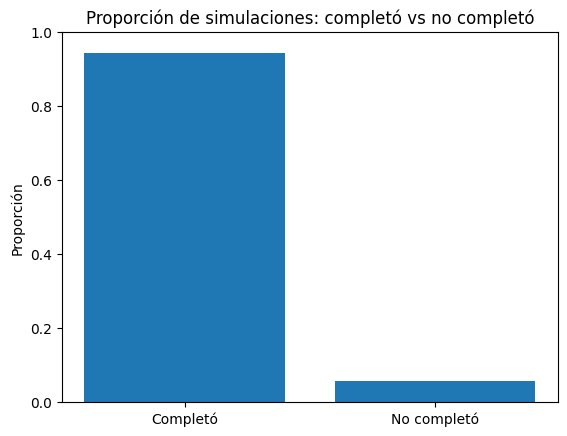

In [13]:
proporciones = [completo.mean(), 1 - completo.mean()]
etiquetas = ["Completó", "No completó"]

plt.bar(etiquetas, proporciones)
plt.ylabel("Proporción")
plt.title("Proporción de simulaciones: completó vs no completó")
plt.ylim(0, 1)
plt.show()

In [19]:
max_sobres    = int(PT // PI)        # sobres enteros que caben en Q1000
min_teorico   = -(-N // S)           # ⌈N/S⌉ sin repetidos (ceil division)
estampas_max  = max_sobres * S       # estampas totales si no hubiera repetidos

print("PREGUNTA 1 – PRESUPUESTO MÁXIMO")
print(f"Sobres máximos con Q{PT}        : {max_sobres}")
print(f"Estampas posibles sin repetidos  : {estampas_max} / {N}")
print(f"Mínimo teórico de sobres ⌈N/S⌉  : {min_teorico}")

PREGUNTA 1 – PRESUPUESTO MÁXIMO
Sobres máximos con Q1000        : 105
Estampas posibles sin repetidos  : 735 / 100
Mínimo teórico de sobres ⌈N/S⌉  : 15


Con un presupuesto de Q1000 es posible comprar 105 sobres, los cuales brindarian 735 estampas distintas, dando una alta posibilidad de completar las 100 estampas necesarias para llenar el album. El minimo teorico de sobres que se necesita para llenar el album es de 15, de tal forma que el presupuesto supera por mucho este minimo; sin emabrgo, se puede reportar escenarios donde no se completa el album debido a la aparicion continua de estampas repetidas en los sobres, dando asi una probabilidad de 94.47% de llenarlo y un 5.53% de no llenarlo.

In [20]:
SOBRES_CAJA = 104
COSTO_CAJA  = 975.0
np.random.seed(2028)

completo_caja = []
for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)
    for _ in range(SOBRES_CAJA):
        sobre = np.random.randint(0, N, size=S)   # misma lógica corregida
        for est in sobre:
            coleccion[est] = True
    completo_caja.append(coleccion.all())

completo_caja = np.array(completo_caja)
prob_caja     = completo_caja.mean()
diferencia    = prob_caja - prob_completar


print("PREGUNTA 2 – CAJA DE 104 SOBRES (Q975)")
print(f"P(completar) caja    : {prob_caja:.4f}  ({prob_caja*100:.2f} %)")
print(f"P(completar) sueltos : {prob_completar:.4f}  ({prob_completar*100:.2f} %)")
print(f"Diferencia           : {diferencia:+.4f}  ({diferencia*100:+.2f})")

PREGUNTA 2 – CAJA DE 104 SOBRES (Q975)
P(completar) caja    : 0.9389  (93.89 %)
P(completar) sueltos : 0.9447  (94.47 %)
Diferencia           : -0.0058  (-0.58 pp)


La caja de 104 sobres cuesta Q975 y ofrece una probabilidad de 93.89%, mientras que comprando sobres sueltos con Q1,000 se obtiene 94.47% con 105 sobres, la diferencia es de apenas de 0.58% puntos porcentuales a favor de los sueltos por el simple hecho que el presupuesto aguanta la compra de dos sobres los cuales no ofrece la caja. Si uno busca ahorrar un poco de dinero, la caja representa una buna opcion pero si se busca aumentar las probabilidades de llenar el album no representa la mejor opcion. 

In [22]:
presupuesto_restante = PT - COSTO_CAJA
sobres_extra         = int(presupuesto_restante // PI)
costo_total_mixto    = COSTO_CAJA + sobres_extra * PI
sobres_total_mixto   = SOBRES_CAJA + sobres_extra

np.random.seed(2027)

completo_mixto = []
for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)
    for _ in range(sobres_total_mixto):
        sobre = np.random.randint(0, N, size=S)
        for est in sobre:
            coleccion[est] = True
    completo_mixto.append(coleccion.all())

completo_mixto = np.array(completo_mixto)
prob_mixto     = completo_mixto.mean()

print("PREGUNTA 3 – ESTRATEGIA MIXTA")
print(f"Sobres totales : {sobres_total_mixto}  (caja + {sobres_extra} sueltos)")
print(f"Gasto total    : Q{costo_total_mixto:.2f} / Q{PT}")
print(f"\n{'Estrategia':<20} {'Sobres':>7} {'Costo':>8} {'P(éxito)':>10}")
print("-" * 47)
print(f"{'Solo sueltos':<20} {max_sobres:>7} {max_sobres*PI:>7.2f}Q {prob_completar*100:>9.2f}%")
print(f"{'Solo caja':<20} {SOBRES_CAJA:>7} {COSTO_CAJA:>7.2f}Q {prob_caja*100:>9.2f}%")
print(f"{'Caja + sueltos':<20} {sobres_total_mixto:>7} {costo_total_mixto:>7.2f}Q {prob_mixto*100:>9.2f}%")

PREGUNTA 3 – ESTRATEGIA MIXTA
Sobres totales : 106  (caja + 2 sueltos)
Gasto total    : Q994.00 / Q1000

Estrategia            Sobres    Costo   P(éxito)
-----------------------------------------------
Solo sueltos             105  997.50Q     94.47%
Solo caja                104  975.00Q     93.89%
Caja + sueltos           106  994.00Q     94.25%


La estrategia mixta (caja + 2 sobres sueltos) usa Q994 de los Q1,000 disponibles y abre 106 sobres en total, pero su probabilidad de 94.25% queda entre las otras dos opciones, mejor que la caja sola pero ligeramente por debajo de solo sueltos. La conclusión práctica es que las tres estrategias son equivalentes dentro del presupuesto de Q1,000, y la elección entre ellas tiene un impacto mínimo en la probabilidad de completar el álbum, pero si se quiere asegurar el escenario de completar el album, la estrategia de comprar solo sueltas resutla ser la mejor al aumentar las probabilidades a 0.22